In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import featuregraph as fg
from featuregraph import training_cycle, test_cycle, plot_arc_agi

In [2]:
train_grid_1 = np.array([
    [1, 2, 3],
    [4, 5, 6],
])

train_output_1 = np.array([
    [1, 2, 3, 3, 2, 1, 4, 5, 6],
    [4, 5, 6, 6, 5, 4, 1, 2, 3],
    [4, 5, 6, 1, 2, 3, 3, 2, 1],
    [1, 2, 3, 4, 5, 6, 6, 5, 4],
])

train_grid_2 = np.array([
    [7, 2],
    [4, 9],
    [1, 6],
])

train_output_2 = np.array([
    [7, 2, 2, 7, 1, 6],
    [4, 9, 9, 4, 4, 9],
    [1, 6, 6, 1, 7, 2],
    [1, 6, 7, 2, 2, 7],
    [4, 9, 4, 9, 9, 4],
    [7, 2, 1, 6, 6, 1],
])

training_pairs = [
    {
        "grid": train_grid_1,
        "output": train_output_1,
    },
    {
        "grid": train_grid_2,
        "output": train_output_2,
    },
]

test_grid = np.array([
    [8, 3],
    [0, 5],
])

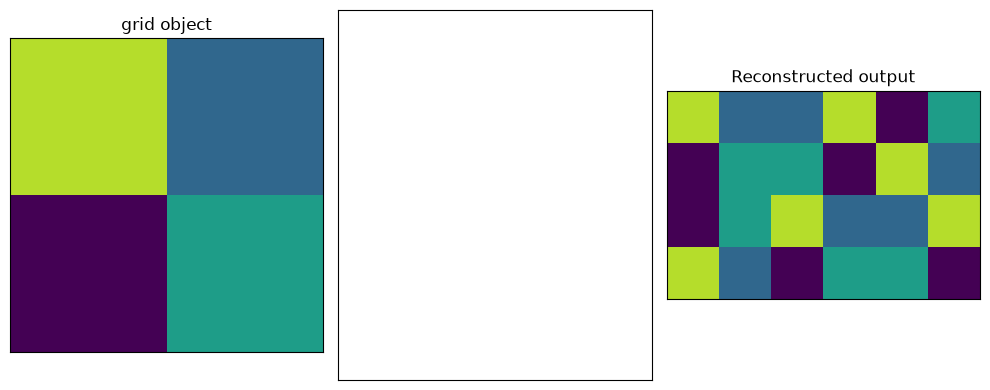

In [3]:
instruction_layout = training_cycle(training_pairs)
prediction = test_cycle(test_grid, instruction_layout)

plot_arc_agi(
    test_grid,
    output=None,
    manual_output=prediction,
)

In [4]:
expected_prediction = np.array([
    [8, 3, 3, 8, 0, 5],
    [0, 5, 5, 0, 8, 3],
    [0, 5, 8, 3, 3, 8],
    [8, 3, 0, 5, 5, 0],
])

assert np.array_equal(prediction, expected_prediction)

print("Successful prediction check passed.")

Successful prediction check passed.


In [5]:
rotation_layout = np.array([
    ["copy", "rotate_90"],
    ["rotate_180", "rotate_270"],
])

rectangular_test_grid = np.array([
    [1, 2, 3],
    [4, 5, 6],
])

try:
    test_cycle(rectangular_test_grid, rotation_layout)
    raise AssertionError(
        "Expected the incompatible grid to be rejected."
    )
except ValueError as error:
    print("Incompatible-grid check passed:")
    print(error)

Incompatible-grid check passed:
Test grid does not support operators: [np.str_('rotate_270'), np.str_('rotate_90')]


In [6]:
no_match_output = training_pairs[0]["output"].copy()
no_match_output[0, 0] = 9

no_match_pairs = [
    {
        "grid": training_pairs[0]["grid"],
        "output": no_match_output,
    }
]

try:
    training_cycle(no_match_pairs)
    raise AssertionError(
        "Expected training to detect a block with no match."
    )
except ValueError as error:
    print("No-match check passed:")
    print(error)

No-match check passed:
No operator matched block (0, 0).


In [7]:
symmetric_grid = np.array([
    [1, 1],
    [1, 1],
])

symmetric_output = np.array([
    [1, 1],
    [1, 1],
])

ambiguous_pairs = [
    {
        "grid": symmetric_grid,
        "output": symmetric_output,
    }
]

try:
    training_cycle(ambiguous_pairs)
    raise AssertionError(
        "Expected training to detect ambiguous operators."
    )
except ValueError as error:
    print("Ambiguity check passed:")
    print(error)

Ambiguity check passed:
Multiple operators remain after all training pairs for block (0, 0): ['copy', 'flip_horizontal', 'flip_vertical', 'rotate_180', 'rotate_270', 'rotate_90']
